# Chronos-2 Context-Length Sweep on data_1to7

This notebook benchmarks **Chronos-2 Zero-Shot** on **`data/data_1to7.csv`** for a fixed
forecast horizon (`48`) while varying context length from `48` to `512`.

To ensure strict comparability across contexts, evaluation uses the **same sampled windows**
for every context (fixed random seed + paired random windows + fixed evaluation start index).

Metrics are saved under `results/evaluation/chronos2_context_sweep/`; figures are saved to `results/plots/`.


In [1]:
from __future__ import annotations

import json
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('Project root:', ROOT)
print('Python:', sys.executable)


Project root: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository
Python: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/bin/python


In [2]:
MODEL = 'chronos2'
DATASET_PATH = ROOT / 'data' / 'data_1to7.csv'
EVAL_DIR = ROOT / 'results' / 'evaluation'
PLOTS_DIR = ROOT / 'results' / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Sweep setup
HORIZON = 48
CONTEXT_LENGTHS = [48, 64, 96, 128, 192, 256, 384, 512]
MAX_CONTEXT = max(CONTEXT_LENGTHS)
SAMPLING_MODE = 'random'
RANDOM_WINDOWS_PER_SERIES = 50
RANDOM_SEED = 42
RANDOM_WITH_REPLACEMENT = True
PAIRED_RANDOM_WINDOWS = True

SWEEP_DIR = EVAL_DIR / 'chronos2_context_sweep'
SWEEP_DIR.mkdir(parents=True, exist_ok=True)

rows = []
for ctx in CONTEXT_LENGTHS:
    out_dir = SWEEP_DIR / f'ctx_{ctx}'
    out_dir.mkdir(parents=True, exist_ok=True)

    cmd = [
        sys.executable,
        str(ROOT / 'src' / 'evaluate.py'),
        '--models', MODEL,
        '--data-path', str(DATASET_PATH),
        '--horizon', str(HORIZON),
        '--context-length', str(ctx),
        '--evaluation-start-index', str(MAX_CONTEXT),
        '--sampling-mode', SAMPLING_MODE,
        '--random-windows-per-series', str(RANDOM_WINDOWS_PER_SERIES),
        '--random-seed', str(RANDOM_SEED),
        '--cp-penalty', '15',
        '--cp-min-size', '10',
        '--output-dir', str(out_dir),
    ]

    if RANDOM_WITH_REPLACEMENT:
        cmd.append('--random-with-replacement')
    else:
        cmd.append('--random-without-replacement')

    if PAIRED_RANDOM_WINDOWS:
        cmd.append('--paired-random-windows')
    else:
        cmd.append('--independent-random-windows')

    print(f'Running context_length={ctx}:', ' '.join(cmd))
    subprocess.run(cmd, cwd=ROOT, check=True)

    metrics_path = out_dir / 'chronos2_metrics.json'
    if not metrics_path.exists():
        raise FileNotFoundError(f'Missing metrics file: {metrics_path}')

    m = json.loads(metrics_path.read_text())
    rows.append({
        'context_length': int(ctx),
        'horizon': int(HORIZON),
        'MAE_CP': float(m['MAE_CP']),
        'coverage_rate': float(m['coverage_rate']),
        'sharpness': float(m['sharpness']),
        'tolerance_hit_rate': float(m['tolerance_hit_rate']),
        'num_windows_total': int(m['num_windows_total']),
        'output_dir': str(out_dir),
    })

metrics_df = pd.DataFrame(rows).sort_values('context_length').reset_index(drop=True)
sweep_csv = SWEEP_DIR / 'chronos2_context_sweep_metrics.csv'
metrics_df.to_csv(sweep_csv, index=False)

print('Completed sweep on dataset:', DATASET_PATH)
print('Same-sample constraint: paired random windows + fixed seed + evaluation_start_index =', MAX_CONTEXT)
print('Saved metrics CSV:', sweep_csv)
display(metrics_df)


Running context_length=48: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/bin/python /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/src/evaluate.py --models chronos2 --data-path /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/data/data_1to7.csv --horizon 48 --context-length 48 --evaluation-start-index 512 --sampling-mode random --random-windows-per-series 50 --random-seed 42 --cp-penalty 15 --cp-min-size 10 --output-dir /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation/chronos2_context_sweep/ctx_48 --random-with-replacement --paired-random-windows


/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/lib/python3.13/site-packages/ruptures/costs/costnormal.py:28: UserWarning: New behaviour in v1.1.5: a small bias is added to the covariance matrix to cope with truly constant segments (see PR#198).
  warnings.warn(


[chronos2] MAE_CP=11.2277 Coverage=0.9629 Sharpness=4.5194
Saved summary: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation/chronos2_context_sweep/ctx_48/evaluation_summary.json
Running context_length=64: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/bin/python /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/src/evaluate.py --models chronos2 --data-path /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/data/data_1to7.csv --horizon 48 --context-length 64 --evaluation-start-index 512 --sampling-mode random --random-windows-per-series 50 --random-seed 42 --cp-penalty 15 --cp-min-size 10 --output-dir /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation/chronos2_context_sweep/ctx_64 --random-with-replacement --paired-random-windows


/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/lib/python3.13/site-packages/ruptures/costs/costnormal.py:28: UserWarning: New behaviour in v1.1.5: a small bias is added to the covariance matrix to cope with truly constant segments (see PR#198).
  warnings.warn(


[chronos2] MAE_CP=11.0723 Coverage=0.9580 Sharpness=4.3487
Saved summary: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation/chronos2_context_sweep/ctx_64/evaluation_summary.json
Running context_length=96: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/bin/python /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/src/evaluate.py --models chronos2 --data-path /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/data/data_1to7.csv --horizon 48 --context-length 96 --evaluation-start-index 512 --sampling-mode random --random-windows-per-series 50 --random-seed 42 --cp-penalty 15 --cp-min-size 10 --output-dir /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation/chronos2_context_sweep/ctx_96 --random-with-replacement --paired-random-windows


...

/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/lib/python3.13/site-packages/ruptures/costs/costnormal.py:28: UserWarning: New behaviour in v1.1.5: a small bias is added to the covariance matrix to cope with truly constant segments (see PR#198).
  warnings.warn(


[chronos2] MAE_CP=10.6081 Coverage=0.9590 Sharpness=3.4943
Saved summary: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation/chronos2_context_sweep/ctx_384/evaluation_summary.json
Running context_length=512: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/bin/python /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/src/evaluate.py --models chronos2 --data-path /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/data/data_1to7.csv --horizon 48 --context-length 512 --evaluation-start-index 512 --sampling-mode random --random-windows-per-series 50 --random-seed 42 --cp-penalty 15 --cp-min-size 10 --output-dir /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation/chronos2_context_sweep/ctx_512 --random-with-replacement --paired-random-windows


/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/lib/python3.13/site-packages/ruptures/costs/costnormal.py:28: UserWarning: New behaviour in v1.1.5: a small bias is added to the covariance matrix to cope with truly constant segments (see PR#198).
  warnings.warn(


[chronos2] MAE_CP=10.3537 Coverage=0.9591 Sharpness=3.4645
Saved summary: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation/chronos2_context_sweep/ctx_512/evaluation_summary.json
Completed sweep on dataset: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/data/data_1to7.csv
Same-sample constraint: paired random windows + fixed seed + evaluation_start_index = 512
Saved metrics CSV: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation/chronos2_context_sweep/chronos2_context_sweep_metrics.csv


,context_length,horizon,MAE_CP,coverage_rate,sharpness,tolerance_hit_rate,num_windows_total,output_dir
0,48,48,11.227674,0.962881,4.519404,0.291860,4300,/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repo...
1,64,48,11.072326,0.958033,4.348707,0.299070,4300,/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repo...
2,96,48,11.046047,0.960057,4.174712,0.302326,4300,/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repo...
3,128,48,10.561163,0.960429,4.153491,0.319767,4300,/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repo...
4,192,48,10.597209,0.960014,3.984370,0.314884,4300,/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repo...
5,256,48,10.581395,0.957343,3.626856,0.322093,4300,/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repo...
6,384,48,10.608140,0.959029,3.494280,0.315116,4300,/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repo...
7,512,48,10.353721,0.959127,3.464484,0.322791,4300,/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repo...


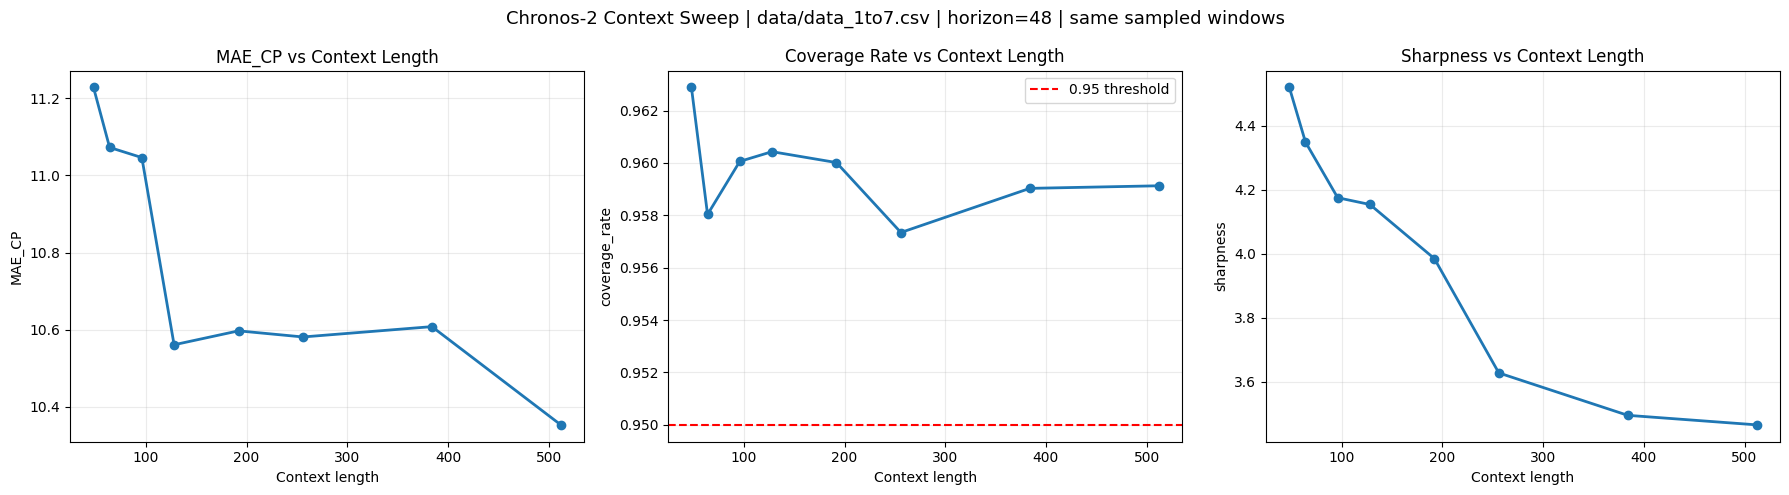

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/benchmark_chronos2_context_sweep_48_to_512.png


In [3]:
if 'metrics_df' not in globals() or metrics_df.empty:
    raise RuntimeError('Run the sweep cell first to populate metrics_df.')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) MAE_CP
axes[0].plot(metrics_df['context_length'], metrics_df['MAE_CP'], marker='o', linewidth=2)
axes[0].set_title('MAE_CP vs Context Length')
axes[0].set_xlabel('Context length')
axes[0].set_ylabel('MAE_CP')
axes[0].grid(alpha=0.25)

# 2) Coverage
axes[1].plot(metrics_df['context_length'], metrics_df['coverage_rate'], marker='o', linewidth=2)
axes[1].axhline(0.95, color='red', linestyle='--', linewidth=1.5, label='0.95 threshold')
axes[1].set_title('Coverage Rate vs Context Length')
axes[1].set_xlabel('Context length')
axes[1].set_ylabel('coverage_rate')
axes[1].grid(alpha=0.25)
axes[1].legend(loc='best')

# 3) Sharpness
axes[2].plot(metrics_df['context_length'], metrics_df['sharpness'], marker='o', linewidth=2)
axes[2].set_title('Sharpness vs Context Length')
axes[2].set_xlabel('Context length')
axes[2].set_ylabel('sharpness')
axes[2].grid(alpha=0.25)

fig.suptitle(
    'Chronos-2 Context Sweep | data/data_1to7.csv | horizon=48 | same sampled windows',
    fontsize=13,
)
plt.tight_layout()

plot_path = PLOTS_DIR / 'benchmark_chronos2_context_sweep_48_to_512.png'
plt.savefig(plot_path, dpi=170, bbox_inches='tight')
plt.show()
print('Saved plot:', plot_path)


In [4]:
if 'metrics_df' not in globals() or metrics_df.empty:
    raise RuntimeError('Run the sweep cell first to populate metrics_df.')

closest_cov_idx = (metrics_df['coverage_rate'] - 0.95).abs().idxmin()
best_cov_row = metrics_df.loc[closest_cov_idx]

best_mae_row = metrics_df.loc[metrics_df['MAE_CP'].idxmin()]
best_sharp_row = metrics_df.loc[metrics_df['sharpness'].idxmin()]

print('Closest to 0.95 coverage:')
display(best_cov_row.to_frame().T)

print('Best MAE_CP (lower is better):')
display(best_mae_row.to_frame().T)

print('Best sharpness (lower is better):')
display(best_sharp_row.to_frame().T)


Closest to 0.95 coverage:


,context_length,horizon,MAE_CP,coverage_rate,sharpness,tolerance_hit_rate,num_windows_total,output_dir
5,256,48,10.581395,0.957343,3.626856,0.322093,4300,/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repo...


Best MAE_CP (lower is better):


,context_length,horizon,MAE_CP,coverage_rate,sharpness,tolerance_hit_rate,num_windows_total,output_dir
7,512,48,10.353721,0.959127,3.464484,0.322791,4300,/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repo...


Best sharpness (lower is better):


,context_length,horizon,MAE_CP,coverage_rate,sharpness,tolerance_hit_rate,num_windows_total,output_dir
7,512,48,10.353721,0.959127,3.464484,0.322791,4300,/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repo...
